In [48]:
import os
import openmc
import numpy as np
from IPython.display import Image, display
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm , Normalize


In [49]:
# pulizia per sicurezza

os.system("rm *.h5")
os.system("rm *.xml")
os.system("rm *.out")
os.system("rm *.png")

rm: cannot remove '*.h5': No such file or directory
rm: cannot remove '*.out': No such file or directory
rm: cannot remove '*.png': No such file or directory


256

VARIABILI IMPORTANTI

In [ ]:
arricchimento = 0.02

# --- PARAMETRI GEOMETRICI ---
R_CORE = 45.0        # Raggio esterno core
R_PIPE = 5.0         # Raggio tubo vuoto centrale
R_FUEL = 0.5         # Raggio barrette di combustibile

CLAD_THICK = 0.5     # Spessore clad
R_PIN = R_FUEL + CLAD_THICK  # Raggio totale pin

H_CORE = 90.0        # Altezza core
REF_SIDE = 15.0       # Spessore riflettore laterale
REF_BOT = 15.0       # Spessore riflettore fondo

R_TARGET = 3.5   # Raggio del target (deve essere < R_PIPE)
H_TARGET = 10.0  # Altezza del target , vedi paper lorenzo
P_TARGET = H_CORE/2 - H_TARGET # posizione del target

PITCH = R_PIN * 2 + 1          # Passo minimo (> del doppio del raggio pin)

S = 1e15    # Intensità della sorgente (gamma al secondo)
photon_energy = 13e6 #energia del mascio monocromatico di fotoni sul target
bin_ris = 300   # Numero di bin per le mesh tally 

batches = 200
particles = 50000

MATERIALI

In [51]:
fuel = openmc.Material(name='fuel')
fuel.add_nuclide('U235', arricchimento)
fuel.add_nuclide('U238', 1.0 - arricchimento)
fuel.add_nuclide('O16', 2.0)
fuel.set_density('g/cm3', 10.96)

# materiale di rivestimento
cladding = openmc.Material (name = 'cladding')
cladding.add_element('Zr', 1.0) 
cladding.set_density('g/cm3', 6.49)

# materiale di moderatore
water = openmc.Material (name = 'water')
water.add_element('H', 2.0)
water.add_element('O', 1.0)
water.set_density('g/cm3', 1.10)
water.add_s_alpha_beta('c_D_in_D2O') # aggiungo la tabella di scattering termico
# n.b.  le sezioni d'urto veloci sono già incluse di default

# aggiungo unriflettore in ACCIAIO INOX
# Usiamo SS316 che è standard, denso e riflette senza moderare troppo
reflector = openmc.Material(name='reflector')
reflector.add_element('Fe', 0.65)
reflector.add_element('Cr', 0.17)
reflector.add_element('Ni', 0.12)
reflector.add_element('Mo', 0.02)
reflector.add_element('Mn', 0.02)
reflector.set_density('g/cm3', 7.9) # Densità alta per riflettere bene

# voglio una sorgente puntiforme di neutroni in un punto specifico
marker_mat = openmc.Material(name='marker')
marker_mat.set_density('g/cm3', 1e-10) # Densità quasi nulla per non disturbare la fisica
marker_mat.add_nuclide('He4', 1.0) # elio, non interagisce praticamente

# Carburo di Boro B4C per le barre di controllo
control_rod = openmc.Material(name='B4C')
control_rod.add_element('B', 4.0)
control_rod.add_element('C', 1.0)
control_rod.set_density('g/cm3', 2.52) # Densità teorica B4C

mat_target = fuel # dal paper di lorenzo si nota un otttimo per U2O


GEOMETRIA

In [52]:
# Cilindri
cyl_pipe = openmc.ZCylinder(r=R_PIPE)
cyl_core = openmc.ZCylinder(r=R_CORE)
cyl_ref_out = openmc.ZCylinder(r=R_CORE + REF_SIDE, boundary_type='vacuum') 

# Target Surfaces
cyl_target = openmc.ZCylinder(r=R_TARGET)

# Piani Z
z_bot_ref = openmc.ZPlane(z0=-REF_BOT, boundary_type='vacuum') 
z_bot_core = openmc.ZPlane(z0=0.0)
z_top_core = openmc.ZPlane(z0=H_CORE)
z_top_world = openmc.ZPlane(z0=H_CORE + 10.0, boundary_type='vacuum') 

# Piani Z Target (Centrato a metà altezza core)
z_mid = H_CORE - P_TARGET
z_tgt_bot = openmc.ZPlane(z0=z_mid - (H_TARGET / 2.0))
z_tgt_top = openmc.ZPlane(z0=z_mid + (H_TARGET / 2.0))


# --- UNIVERSO PIN ---
u_pin = openmc.Universe()
pin_fuel_cyl = openmc.ZCylinder(r=R_FUEL)
pin_clad_cyl = openmc.ZCylinder(r=R_PIN)
c_fuel = openmc.Cell(fill=fuel, region=-pin_fuel_cyl)
c_clad = openmc.Cell(fill=cladding, region=+pin_fuel_cyl & -pin_clad_cyl)
c_mod_local = openmc.Cell(fill=water, region=+pin_clad_cyl) 
u_pin.add_cells([c_fuel, c_clad, c_mod_local])


# ---  ALGORITMO DI RIEMPIMENTO ---
region_water_core = -cyl_core & +cyl_pipe & +z_bot_core & -z_top_core
fuel_cells = []
placed_count = 0
r_curr = R_PIPE + PITCH 

while (r_curr + R_PIN) < R_CORE:
    circumference = 2 * np.pi * r_curr
    n_ring = int(circumference / PITCH)
    
    if n_ring > 0:
        d_theta = 360.0 / n_ring
        for i in range(n_ring):
            theta = np.radians(i * d_theta)
            x = r_curr * np.cos(theta)
            y = r_curr * np.sin(theta)
            
            # Creazione Cella Barra
            cyl_loc = openmc.ZCylinder(r=R_PIN, x0=x, y0=y)
            region_bar = -cyl_loc & +z_bot_core & -z_top_core
            
            cell_bar = openmc.Cell(fill=u_pin, region=region_bar)
            cell_bar.translation = (x, y, 0)
            fuel_cells.append(cell_bar)
            
            # Sottrazione dall'Acqua
            region_water_core &= ~region_bar 
            placed_count += 1
            
    r_curr += PITCH

print(f"Geometria generata. Riempimento completato con {placed_count} barre.")


# ---  DEFINIZIONE CELLE RESTANTI ---

# A. Target 
# Il target è un cilindro solido limitato dai suoi piani Z
region_target = -cyl_target & +z_tgt_bot & -z_tgt_top
c_target = openmc.Cell(fill=mat_target, region=region_target)

# B. Tubo Centrale 
# Il tubo è vuoto (fill=None), MA dobbiamo sottrarre (~) la regione occupata dal target
# per evitare sovrapposizioni (Geometry Overlap).
region_pipe_total = -cyl_pipe & +z_bot_core & -z_top_core
c_pipe = openmc.Cell(fill=None, region=region_pipe_total & ~region_target)

# C. Acqua Core
c_water_core = openmc.Cell(fill=water, region=region_water_core)

# D. Riflettori
c_ref_side = openmc.Cell(fill=reflector, region=+cyl_core & -cyl_ref_out & +z_bot_core & -z_top_core)
c_ref_bot = openmc.Cell(fill=reflector, region=-cyl_ref_out & +z_bot_ref & -z_bot_core)

# E. Zona sopra il core (Vuoto + Sorgente)
# Modifico la posizione della sorgente visiva per metterla sopra il target
sphere_src = openmc.Sphere(x0=0, y0=0, z0=H_CORE + 2, r=0.5)
c_source_marker = openmc.Cell(fill=marker_mat, region=-sphere_src)

region_top = -cyl_ref_out & +z_top_core & -z_top_world & +sphere_src
c_top_void = openmc.Cell(fill=None, region=region_top)


# ---  EXPORT XML ---
all_cells = [c_pipe, c_target, c_water_core, c_ref_side, c_ref_bot, c_source_marker, c_top_void] + fuel_cells
geometry = openmc.Geometry(all_cells)
geometry.export_to_xml()

Geometria generata. Riempimento completato con 610 barre.


SETTING EIGENVALUED

In [53]:

settings_k = openmc.Settings()
settings_k.run_mode = 'eigenvalue'
settings_k.batches = batches
settings_k.particles = particles

# Sorgente spaziale uniforme limitata al volume del combustibile
# Definiamo un box che racchiude il core
lower_left = [-R_CORE, -R_CORE, 0.0]
upper_right = [R_CORE, R_CORE, H_CORE]
uniform_dist = openmc.stats.Box(lower_left, upper_right, only_fissionable=True)

settings_k.source = openmc.IndependentSource(space=uniform_dist)

settings_k.temperature = {'method': 'interpolation'} # Per abilitare l'interpolazione delle temperature nei materiali, se supportata dalle tabelle di sezioni d'urto.

# Esportazione (sovrascrive settings.xml)
settings_k.export_to_xml()


/home/bossi_ricky/miniconda3/envs/openmc-env/lib/python3.11/site-packages/openmc/stats/multivariate.py:960: FutureWarning: The 'only_fissionable' has been deprecated. Use the 'constraints' argument when defining a source instead.
  warn("The 'only_fissionable' has been deprecated. Use the "


In [54]:
k_eff_values = []
k_eff_stds   = []
T_list = []

for T in range(300, 1500, 50):
    print(f"Simulazione a {T} K")

    fuel.temperature = T
    cladding.temperature = T
    reflector.temperature = T
    control_rod.temperature = T
    if T > 600:
        water.temperature = 600.0 # Cap massimo consentito dalla libreria
    else:
        water.temperature = T

    materials = openmc.Materials([fuel, cladding, water, reflector, marker_mat])

    materials.cross_sections = "/home/bossi_ricky/openmc_data/mcnp_endfb71/cross_sections.xml" # per fotonucleari

    materials.export_to_xml()

    percorso_eseguibile = "/home/bossi_ricky/miniconda3/envs/openmc-env/bin/openmc"
    openmc.run(openmc_exec=percorso_eseguibile, output=False)

    sp_filename = f'statepoint.{batches}.h5'
    
    # Apriamo il file, leggiamo k_eff e chiudiamo subito
    with openmc.StatePoint(sp_filename) as sp:
        k_val = sp.k_combined.nominal_value  # Valore medio
        k_std = sp.k_combined.std_dev        # Deviazione standard
        
        k_eff_values.append(k_val)
        k_eff_stds.append(k_std)
        T_list.append(T)
        print(f"    Risultato: k = {k_val:.5f} +/- {k_std:.5f}")

    # Cancella il file statepoint per risparmiare spazio su disco
    if os.path.exists(sp_filename):
        os.remove(sp_filename)
    if os.path.exists('summary.h5'):
        os.remove('summary.h5')



Simulazione a 300 K


/home/bossi_ricky/miniconda3/envs/openmc-env/lib/python3.11/site-packages/openmc/statepoint.py:287: FutureWarning: The 'k_combined' property has been renamed to 'keff' and will be removed in a future version of OpenMC.
  warnings.warn(


    Risultato: k = 0.83696 +/- 0.00946
Simulazione a 350 K


/home/bossi_ricky/miniconda3/envs/openmc-env/lib/python3.11/site-packages/openmc/statepoint.py:287: FutureWarning: The 'k_combined' property has been renamed to 'keff' and will be removed in a future version of OpenMC.
  warnings.warn(


    Risultato: k = 0.83536 +/- 0.00976
Simulazione a 400 K


...

/home/bossi_ricky/miniconda3/envs/openmc-env/lib/python3.11/site-packages/openmc/statepoint.py:287: FutureWarning: The 'k_combined' property has been renamed to 'keff' and will be removed in a future version of OpenMC.
  warnings.warn(


    Risultato: k = 0.81850 +/- 0.00955
Simulazione a 1400 K


/home/bossi_ricky/miniconda3/envs/openmc-env/lib/python3.11/site-packages/openmc/statepoint.py:287: FutureWarning: The 'k_combined' property has been renamed to 'keff' and will be removed in a future version of OpenMC.
  warnings.warn(


    Risultato: k = 0.81620 +/- 0.01246
Simulazione a 1450 K
    Risultato: k = 0.81054 +/- 0.00946


/home/bossi_ricky/miniconda3/envs/openmc-env/lib/python3.11/site-packages/openmc/statepoint.py:287: FutureWarning: The 'k_combined' property has been renamed to 'keff' and will be removed in a future version of OpenMC.
  warnings.warn(


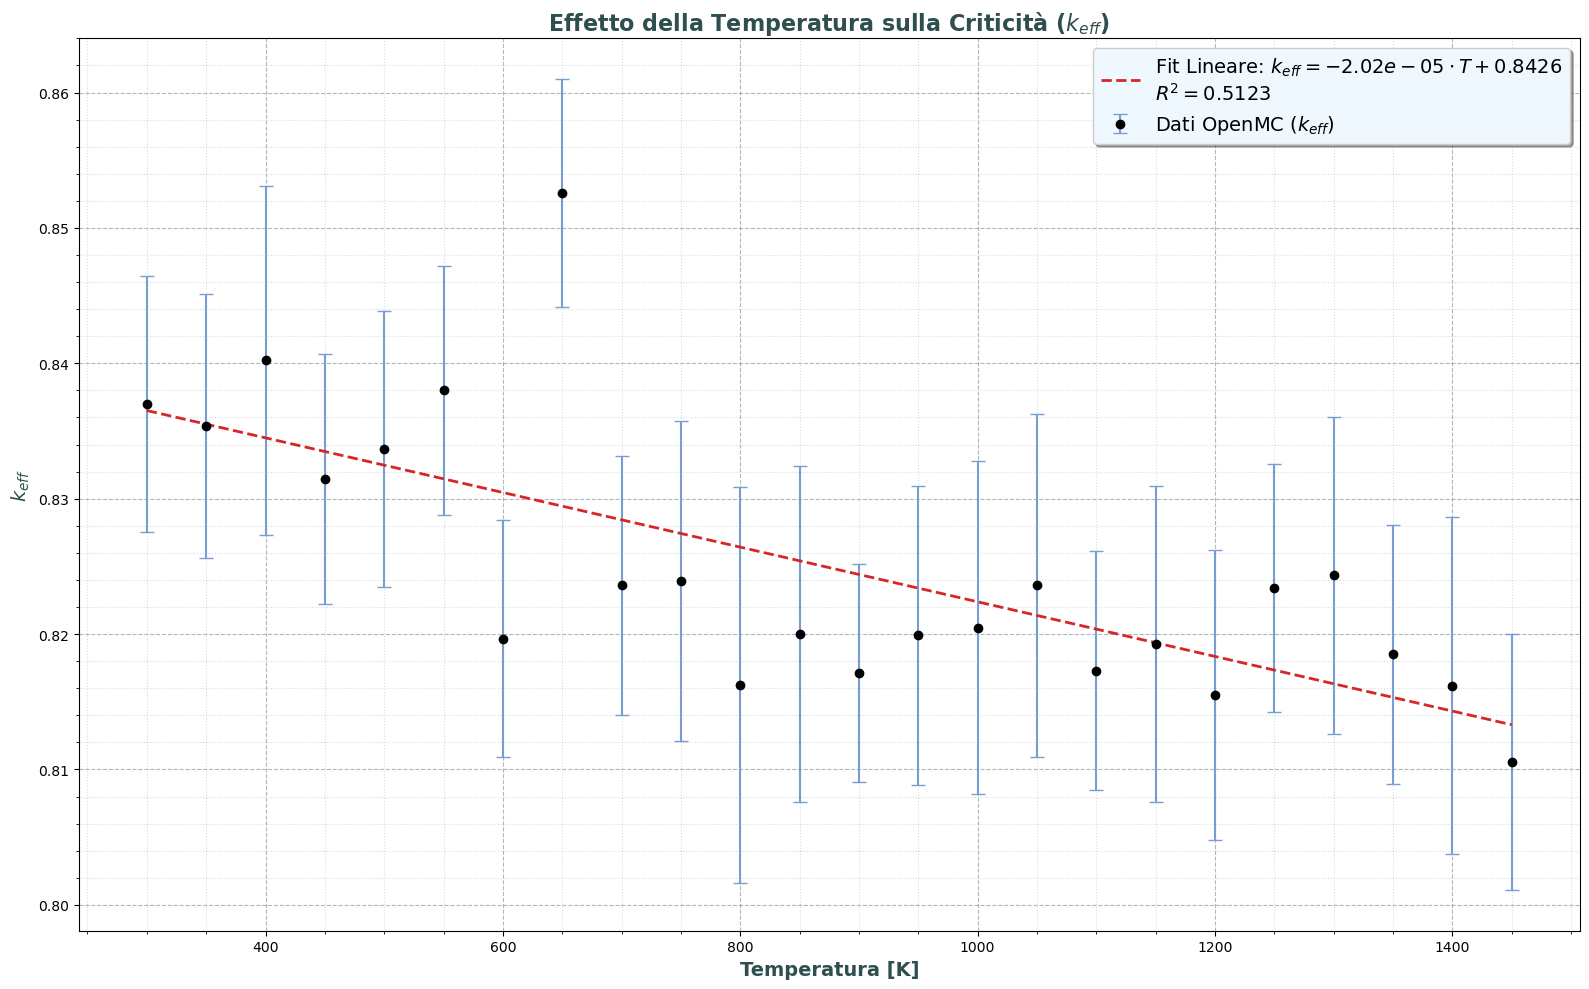

Coefficiente di Temperatura (Slope): -2.01837e-05 [1/K]
Intercetta: 0.84257
R-squared: 0.51231


In [58]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress

slope, intercept, r_value, p_value, std_err = linregress(T_list, k_eff_values)
r_squared = r_value**2

# Generazione punti per la retta
fit_x = np.array(T_list)
fit_y = slope * fit_x + intercept

plt.figure(figsize=(16, 10))

# Plot dei dati con barre d'errore
plt.errorbar(T_list, k_eff_values, yerr=k_eff_stds, 
             fmt='o', color='#000000', ecolor='#789DD1', 
             capsize=5, label='Dati OpenMC ($k_{eff}$)')

# Plot della retta di fit
# Inseriamo l'equazione e R^2 in legenda
label_fit = f'Fit Lineare: $k_{{eff}} = {slope:.2e} \cdot T + {intercept:.4f}$\n$R^2 = {r_squared:.4f}$'
plt.plot(fit_x, fit_y, color='#D62728', linestyle='--', linewidth=2, label=label_fit)

# --- 3. FORMATTAZIONE ---
plt.title('Effetto della Temperatura sulla Criticità ($k_{eff}$)', fontsize=16, fontweight='bold', color='#2F4F4F')
plt.xlabel('Temperatura [K]', fontsize=14, fontweight='bold', color='#2F4F4F')
plt.ylabel('$k_{eff}$', fontsize=14, fontweight='bold', color='#2F4F4F')

# Griglia personalizzata
plt.minorticks_on()
plt.grid(which='major', linestyle='--', alpha=0.6, color='#778899')
plt.grid(which='minor', linestyle=':', alpha=0.3, color='#778899')

# Legenda unificata
plt.legend(loc='upper right', frameon=True, shadow=True, fontsize=14, facecolor='#F0F8FF')

plt.tight_layout()
plt.show()

# Output numerico rapido
print(f"Coefficiente di Temperatura (Slope): {slope:.5e} [1/K]")
print(f"Intercetta: {intercept:.5f}")
print(f"R-squared: {r_squared:.5f}")